behavioral + commercial segmentation

K-Prototypes
Customer Personas for Retention Action Routing

Customer Data  
   ↓  
K-Prototypes Segmentation  
   ↓  
Cluster Persona Labels  
   ↓  
(Churn Probability + SHAP)  
   ↓  
Retention Action  

Persona (cluster)  

\+  

Urgency (churn probability bucket)  

\+  

Reason (SHAP)  

=  

Action  

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from datetime import datetime, timezone

PROCESSED_DATA_PATH = "../data/processed/telco_customer_churn_clean.csv"
SEGMENTATION_MODEL_PATH = "../artifacts/customer_segmentation_package.joblib"

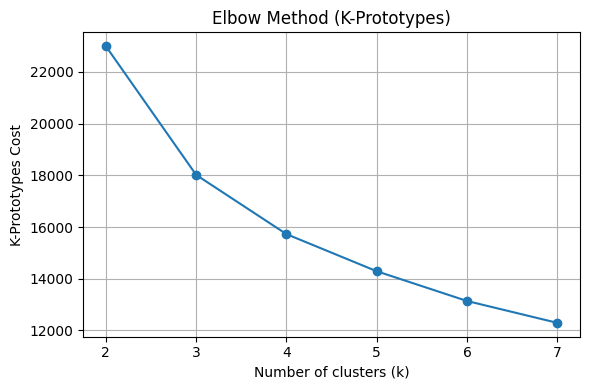

In [2]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

cat_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

df = pd.read_csv(PROCESSED_DATA_PATH)

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

X_cluster = df[num_cols + cat_cols]

categorical_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

# Elbow search
cost = []

for k in range(2, 8):
    kp = KPrototypes(n_clusters=k, init="Huang", random_state=42)
    kp.fit_predict(X_cluster, categorical=categorical_idx)
    cost.append(kp.cost_)

# Plot elbow
plt.figure(figsize=(6,4))
plt.plot(range(2,8), cost, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("K-Prototypes Cost")
plt.title("Elbow Method (K-Prototypes)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
N_CLUSTERS = 4

kproto = KPrototypes(
    n_clusters=N_CLUSTERS,
    init="Huang",
    random_state=42
)

clusters = kproto.fit_predict(
    X_cluster,
    categorical=categorical_idx
)

df["cluster"] = clusters

# Cluster profiling
cluster_numeric = df.groupby("cluster")[num_cols].mean().round(2)

cluster_categorical = df.groupby("cluster")[cat_cols].agg(
    lambda x: x.value_counts().idxmax()
)

print("\nNumeric Cluster Profiles:")
display(cluster_numeric)

print("\nCategorical Cluster Profiles:")
display(cluster_categorical)

print("\nCluster Size Distribution:")
cluster_sizes = df["cluster"].value_counts(normalize=True).round(3)
display(cluster_sizes)


Numeric Cluster Profiles:


,tenure,MonthlyCharges,TotalCharges
cluster,,,
0,1.11,0.94,1.44
1,-0.65,0.57,-0.42
2,0.86,-1.06,-0.23
3,-0.88,-1.00,-0.84



Categorical Cluster Profiles:


,Contract,InternetService,PaymentMethod,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling
cluster,,,,,,,,,,,
0,Two year,Fiber optic,Credit card (automatic),Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
1,Month-to-month,Fiber optic,Electronic check,No,No,No,No,No,No,No,Yes
2,Two year,No,Bank transfer (automatic),No,No,No,No,No,No,No,No
3,Month-to-month,DSL,Mailed check,No,No,No,No,No,No,No,No



Cluster Size Distribution:


cluster
1    0.313
0    0.268
3    0.261
2    0.159
Name: proportion, dtype: float64

Explained variance: [0.38611721 0.15585211]


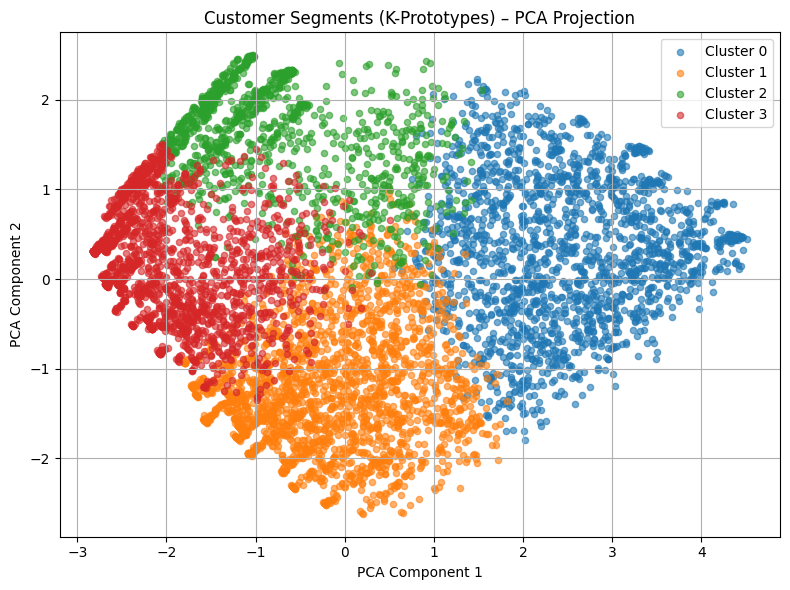

In [4]:
# PCA visualization (for reporting only)
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_cat_ohe = ohe.fit_transform(df[cat_cols])
X_num = df[num_cols].values

X_vis = np.hstack([X_num, X_cat_ohe])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vis)

print("Explained variance:", pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))

for c in sorted(df["cluster"].unique()):
    mask = df["cluster"] == c
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {c}",
        alpha=0.6,
        s=20
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments (K-Prototypes) – PCA Projection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
# Package segmentation pipeline (production artifact)
segmentation_package = {
    "model": kproto,
    "scaler": scaler,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "categorical_idx": categorical_idx,
    "n_clusters": N_CLUSTERS,
    "cluster_sizes": cluster_sizes.to_dict(),
    "trained_on": datetime.now(timezone.utc).isoformat()
}

joblib.dump(segmentation_package, SEGMENTATION_MODEL_PATH)

print(f"\nSegmentation package saved to:\n{SEGMENTATION_MODEL_PATH}")


Segmentation package saved to:
../artifacts/customer_segmentation_package.joblib
